In [55]:
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import unicodedata
import re
from scipy import stats

In [43]:
def chronic_flag(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"não", "nao"}:
        return "Não"
    if "desconhe" in s:
        return "Desconhecido"
    return "Sim"  # qualquer outra coisa é descrição => tem doença crónica


def norm_yesno(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"sim", "s", "yes", "y", "true", "1"}:
        return "Sim"
    if s in {"não", "nao", "n", "no", "false", "0"}:
        return "Não"
    return str(x).strip()


def strip_accents(s: str) -> str:
    return "".join(
        ch for ch in unicodedata.normalize("NFD", s)
        if unicodedata.category(ch) != "Mn"
    )

def clean_text(x) -> str:
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = strip_accents(s)
    s = re.sub(r"\s+", " ", s)
    return s

def motive_primary(s: str) -> str:
    if re.search(r"suicid|ideacao", s):
        return "Suicidalidade (tentativa/ideação)"
    if re.search(r"deliri", s):
        return "Delirium"
    if re.search(r"agit|heteroagress|labilidade", s):
        return "Agitação/alteração comportamental"
    if re.search(r"ansiedad|anseidad|panico", s):
        if re.search(r"sono|inson|pesadel", s):
            return "Ansiedade + sono"
        return "Ansiedade"
    if re.search(r"sono|inson|pesadel", s):
        return "Perturbação do sono/pesadelos"
    if re.search(r"humor|depress", s):
        return "Humor deprimido"
    if re.search(r"luto", s):
        return "Luto"
    if re.search(r"toxic|toxicos|privacao|abstin", s):
        return "Tóxicos/privação/abstinência"
    if re.search(r"agressao|abuso", s):
        return "Agressão/abuso (alegação)"
    if re.search(r"somatiza", s):
        return "Somatização"
    return "Outro/Não especificado"

def follow_status(s: str) -> str:
    if not s:
        return "Desconhecido"
    if "faleceu" in s or "obito" in s:
        return "Óbito"
    if "sem registos" in s:
        return "Desconhecido (sem registos)"
    if "sem possibilidade de saber" in s:
        return "Desconhecido (privado/incerto)"
    if "sem seguimento" in s or "nao teve seguimento" in s:
        return "Sem seguimento"
    if "perdeu seguimento" in s or ("perde" in s and "seguimento" in s):
        return "Perdeu seguimento"
    if re.search(r"\balta\b", s):
        return "Alta/terminou seguimento"
    if re.search(r"mantem|mantev|mantinha", s) and "seguimento" in s:
        return "Mantém seguimento"
    if "seguida" in s:
        return "Mantém seguimento"
    if "ultima consulta" in s:
        return "Teve seguimento (última consulta registada)"
    return "Desconhecido"

df["Continuidade_psiq"] = df["Status_seguimento_psiq"].replace({
    "Mantém seguimento": "Continua",
    "Alta/terminou seguimento": "Concluiu (alta)",
    "Perdeu seguimento": "Interrompeu/perdeu",
    "Sem seguimento": "Sem seguimento",
    "Óbito": "Óbito",
    "Teve seguimento (última consulta registada)": "Teve seguimento (incerto se continua)",
    "Desconhecido (sem registos)": "Desconhecido",
    "Desconhecido (privado/incerto)": "Desconhecido",
    "Desconhecido": "Desconhecido"
})

def resumo_cont(series: pd.Series) -> dict:
    s = series.dropna()
    return {
        "n": int(s.shape[0]),
        "média": float(s.mean()) if len(s) else np.nan,
        "dp": float(s.std(ddof=1)) if len(s) > 1 else np.nan,
        "mediana": float(s.median()) if len(s) else np.nan,
        "p25": float(s.quantile(0.25)) if len(s) else np.nan,
        "p75": float(s.quantile(0.75)) if len(s) else np.nan,
        "mín": float(s.min()) if len(s) else np.nan,
        "máx": float(s.max()) if len(s) else np.nan,
    }

def resumo_cat(series: pd.Series) -> pd.DataFrame:
    vc = series.value_counts(dropna=False)
    out = pd.DataFrame({
        "n": vc,
        "%": (vc / len(series) * 100).round(1)
    })
    return out

In [7]:
df = pd.read_csv('./data.csv')


In [16]:
df.rename(columns={'Qual': 'Doença Psiquiatrica Diagnosticada'}, inplace=True)

In [ ]:
#remover espaços em branco 
df.columns = [c.strip() for c in df.columns]

In [20]:
PII_COLS = ["", "nº processo"]  # "" é a coluna do nome(está vazia como header
df = df.drop(columns=[c for c in PII_COLS if c in df.columns]).copy()

In [21]:
# Datas (dayfirst=True porque datas PT normalmente são dd/mm/aaaa)
for col in ["Data de nascimento", "Data de admissao na UCIPed", "Data_alta_UCIPed"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", dayfirst=True)

In [22]:
df["Idade"] = pd.to_numeric(df["Idade"], errors="coerce")
df["Tempo_total_UCIP_dias"] = pd.to_numeric(df["Tempo_total_UCIP_dias"], errors="coerce")

# "Dias de ventilação" tem 1 valor em texto no teu ficheiro, então vira NaN (errors="coerce")
df["Dias_vent"] = pd.to_numeric(df["Dias de ventilação"], errors="coerce")
df["Dias_sedo"] = pd.to_numeric(df["Dias de sedoanalgesia"], errors="coerce")


In [25]:

df["Ventilacao"] = df["Ventilação"].apply(norm_yesno)
df["Sedo_analgesia"] = df["Sedo-analgia"].apply(norm_yesno)
df["Prev_psiq"] = df["Doença psiquiátrica prévia"].apply(norm_yesno)
df["Meds_psiq_iniciada"] = df["Medicação psiquiátrica iniciada"].apply(norm_yesno)
df["Seguimento_psic"] = df["Seguimento psic após alta"].apply(norm_yesno)

In [27]:
df["Prev_cronica"] = df["Doença crónica PRÉVIA"].apply(chronic_flag)
df["Prev_cronica_detalhe"] = np.where(
    df["Prev_cronica"] == "Sim",
    df["Doença crónica PRÉVIA"].astype(str).str.strip(),
    np.nan
)

In [28]:
df["Ano_admissao"] = df["Data de admissao na UCIPed"].dt.year

In [32]:
df["Categoria_diagnóstico"] = df["Categoria_diagnóstico"].astype(str).str.strip().str.capitalize()

In [37]:
df["motive_clean"] = df["Motivo de apoio psicológico"].apply(clean_text)

In [38]:
df["Motivo_ref_primary"] = df["motive_clean"].apply(motive_primary)

In [39]:
df["follow_text"] = df["Duração do seguimento"].apply(clean_text)

In [41]:
df["Status_seguimento_psiq"] = df["follow_text"].apply(follow_status)

In [44]:
print("=== TAMANHO DA AMOSTRA ===")
print("N =", len(df))

print("\n=== COBERTURA TEMPORAL (admissão/alta) ===")
print("Admissão (min/max):", df["Data de admissao na UCIPed"].min(), "->", df["Data de admissao na UCIPed"].max())
print("Alta (min/max):    ", df["Data_alta_UCIPed"].min(), "->", df["Data_alta_UCIPed"].max())

print("\nCasos por ano de admissão:")
print(df["Ano_admissao"].value_counts().sort_index())

print("\n=== MISSINGNESS (quantos NaN por coluna) ===")
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

=== TAMANHO DA AMOSTRA ===
N = 38

=== COBERTURA TEMPORAL (admissão/alta) ===
Admissão (min/max): 2021-01-31 00:00:00 -> 2025-12-31 00:00:00
Alta (min/max):     2021-01-31 00:00:00 -> 2026-01-02 00:00:00

Casos por ano de admissão:
Ano_admissao
2021     5
2022    10
2023     5
2024    11
2025     7
Name: count, dtype: int64

=== MISSINGNESS (quantos NaN por coluna) ===
Doença Psiquiatrica Diagnosticada    23
Prev_cronica_detalhe                 19
Unnamed: 18                           4
Data de nascimento                    1
Dias_vent                             1
dtype: int64


In [45]:
print("\n=== DEMOGRAFIA / ANTECEDENTES ===")
print("\nIdade:", resumo_cont(df["Idade"]))
print("\nSexo:\n", resumo_cat(df["Sexo"]))
print("\nDoença crónica prévia (flag):\n", resumo_cat(df["Prev_cronica"]))
print("\nDoença psiquiátrica prévia:\n", resumo_cat(df["Prev_psiq"]))


=== DEMOGRAFIA / ANTECEDENTES ===

Idade: {'n': 38, 'média': 12.631578947368421, 'dp': 4.129138727232835, 'mediana': 14.0, 'p25': 11.0, 'p75': 16.0, 'mín': 2.0, 'máx': 17.0}

Sexo:
             n     %
Sexo               
Feminino   22  57.9
Masculino  16  42.1

Doença crónica prévia (flag):
                n     %
Prev_cronica          
Sim           19  50.0
Não           18  47.4
Desconhecido   1   2.6

Doença psiquiátrica prévia:
             n     %
Prev_psiq          
Não        24  63.2
Sim        14  36.8


In [46]:
print("\n=== INTERNAMENTO UCIP / SUPORTE ===")
print("\nTempo total UCIP (dias):", resumo_cont(df["Tempo_total_UCIP_dias"]))
print("\nVentilação:\n", resumo_cat(df["Ventilacao"]))
print("\nDias de ventilação (numérico):", resumo_cont(df["Dias_vent"]))
print("\nSedo-analgesia:\n", resumo_cat(df["Sedo_analgesia"]))
print("\nDias de sedo-analgesia:", resumo_cont(df["Dias_sedo"]))
print("\nMedicação psiquiátrica iniciada:\n", resumo_cat(df["Meds_psiq_iniciada"]))
print("\nDestino após UCIP:\n", resumo_cat(df["Alta UCIP destino"]))



=== INTERNAMENTO UCIP / SUPORTE ===

Tempo total UCIP (dias): {'n': 38, 'média': 14.473684210526315, 'dp': 29.787297167521437, 'mediana': 5.5, 'p25': 3.0, 'p75': 14.25, 'mín': 0.0, 'máx': 182.0}

Ventilação:
              n     %
Ventilacao          
Sim         27  71.1
Não         11  28.9

Dias de ventilação (numérico): {'n': 37, 'média': 8.81081081081081, 'dp': 16.239249157926402, 'mediana': 2.0, 'p25': 0.0, 'p75': 12.0, 'mín': 0.0, 'máx': 85.0}

Sedo-analgesia:
                  n     %
Sedo_analgesia          
Sim             33  86.8
Não              5  13.2

Dias de sedo-analgesia: {'n': 38, 'média': 12.868421052631579, 'dp': 25.174172793121183, 'mediana': 5.0, 'p25': 2.25, 'p75': 17.25, 'mín': 0.0, 'máx': 152.0}

Medicação psiquiátrica iniciada:
                      n     %
Meds_psiq_iniciada          
Sim                 21  55.3
Não                 17  44.7

Destino após UCIP:
                                       n     %
Alta UCIP destino                            
Tran

In [47]:
print("\n=== DIAGNÓSTICO ===")
print("\nCategoria diagnóstico:\n", resumo_cat(df["Categoria_diagnóstico"]))



=== DIAGNÓSTICO ===

Categoria diagnóstico:
                               n     %
Categoria_diagnóstico                
Trauma                       15  39.5
Acidentes e causas externas   7  18.4
Neurológico                   5  13.2
Respiratório                  5  13.2
Infeccioso/sepsis             3   7.9
Outro                         2   5.3
Cardíaco                      1   2.6


In [48]:
print("\n=== MOTIVO DE REFERENCIAÇÃO (primário) ===")
print(resumo_cat(df["Motivo_ref_primary"]))


=== MOTIVO DE REFERENCIAÇÃO (primário) ===
                                   n     %
Motivo_ref_primary                        
Suicidalidade (tentativa/ideação)  9  23.7
Agitação/alteração comportamental  8  21.1
Ansiedade                          6  15.8
Perturbação do sono/pesadelos      5  13.2
Delirium                           2   5.3
Luto                               2   5.3
Humor deprimido                    1   2.6
Tóxicos/privação/abstinência       1   2.6
Somatização                        1   2.6
Outro/Não especificado             1   2.6
Ansiedade + sono                   1   2.6
Agressão/abuso (alegação)          1   2.6


In [49]:
print("\n=== SEGUIMENTO PSICOLÓGICO APÓS ALTA ===")
print(resumo_cat(df["Seguimento_psic"]))


=== SEGUIMENTO PSICOLÓGICO APÓS ALTA ===
                  n     %
Seguimento_psic          
Sim              28  73.7
Não              10  26.3


In [50]:
print("\n=== SEGUIMENTO PSIQUIÁTRICO===")
print(resumo_cat(df["Continuidade_psiq"]))


=== SEGUIMENTO PSIQUIÁTRICO (texto codificado) ===
                                        n     %
Continuidade_psiq                              
Continua                               15  39.5
Interrompeu/perdeu                      9  23.7
Sem seguimento                          6  15.8
Concluiu (alta)                         3   7.9
Desconhecido                            2   5.3
Óbito                                   2   5.3
Teve seguimento (incerto se continua)   1   2.6


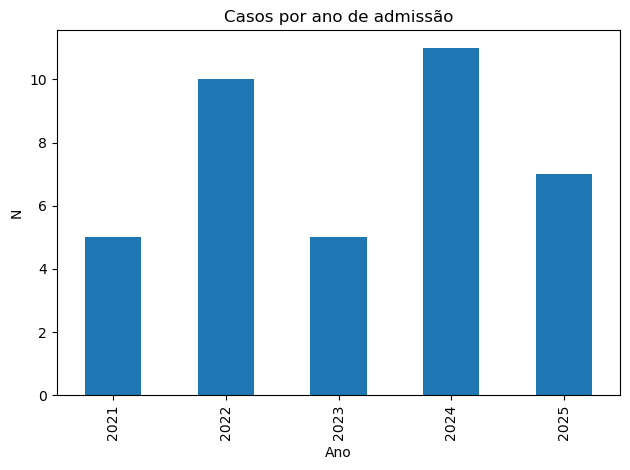

In [51]:
df["Ano_admissao"].value_counts().sort_index().plot(kind="bar")
plt.title("Casos por ano de admissão")
plt.xlabel("Ano")
plt.ylabel("N")
plt.tight_layout()
plt.show()

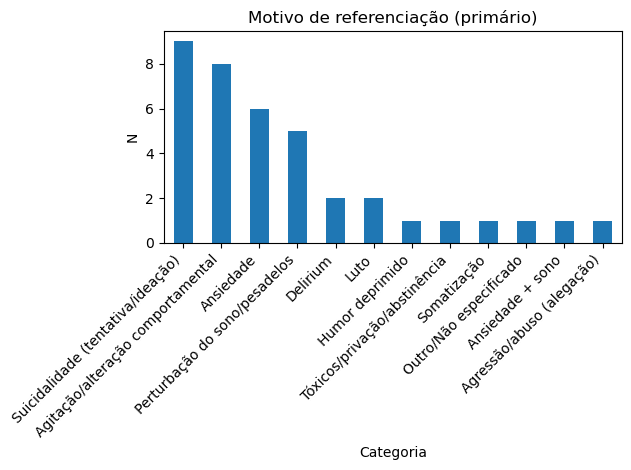

In [52]:
df["Motivo_ref_primary"].value_counts().plot(kind="bar")
plt.title("Motivo de referenciação (primário)")
plt.xlabel("Categoria")
plt.ylabel("N")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()